# Laptop Price Prediction - Regression Track (Algorithms 1-5)

## Scope of this notebook

This notebook studies the first five regression approaches used for the laptop-price prediction problem:

1. **Linear Regression**
2. **Ridge Regression**
3. **Lasso Regression**
4. **ElasticNet Regression**
5. **Polynomial Regression**

The objective is not only to train the models, but also to understand what each method assumes, how its objective function is constructed, how regularisation changes the fitted coefficients, and how the resulting predictions behave on unseen data.

## 1. Why the preprocessing notebook is kept separate

The raw laptop data is transformed in a separate preprocessing notebook, and its final output is saved as `regression.csv`. Keeping that stage separate makes the modelling workflow easier to follow: this notebook starts from the prepared regression representation and concentrates on exploratory analysis, train/test separation, model fitting, comparison, tuning, and diagnostics.

The regression notebook therefore treats `regression.csv` as its modelling input. Only transformations that belong to the modelling stage, such as scaling learned from the training data, are performed here.

In [1]:
# Core Python libraries
import os
import warnings
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
# Scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

# Reproducibility requirement from the capstone guidelines
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


## 2. Load the preprocessed regression dataset

The file `regression.csv` contains the numerical and encoded predictor variables together with the continuous target `price`. The raw file is deliberately not loaded in this notebook because raw-data cleaning and feature construction have already been handled in the dedicated preprocessing stage.

The first check is still performed here because model training should always begin with an audit of the exact data representation that enters the estimators. This lets us verify the dimensions, data types, missing values, duplicate representation, and target scale before any train/test split is created.

In [2]:
df = pd.read_csv("data/regression.csv")


print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1243, 43)


,inches,ram,weight,is_ips,is_touchscreen,res_width,res_height,storage_gb,has_ssd,has_hdd,ppi,company_Apple,company_Asus,company_Chuwi,company_Dell,company_Fujitsu,company_Google,company_Hp,company_Huawei,company_Lenovo,company_Lg,company_Mediacom,company_Microsoft,company_Msi,company_Razer,company_Samsung,company_Toshiba,company_Vero,company_Xiaomi,typename_Gaming,typename_Netbook,typename_Notebook,typename_Ultrabook,typename_Workstation,opsys_Chrome Os,opsys_Linux,opsys_Mac Os X,opsys_Macos,opsys_No Os,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7,price
0,13.3000,8.0000,1.3700,1,0,2560,1600,128.0000,1,0,226.9830,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"71,378.6832"
1,13.3000,8.0000,1.3400,0,0,1440,900,128.0000,0,0,127.6779,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"47,895.5232"
2,15.6000,8.0000,1.8600,0,0,1920,1080,256.0000,1,0,141.2120,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,"30,636.0000"
3,15.4000,16.0000,1.8300,1,0,2880,1800,512.0000,1,0,220.5346,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"135,195.3360"
4,13.3000,8.0000,1.3700,1,0,2560,1600,256.0000,1,0,226.9830,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,"96,095.8080"


## 3. Dataset audit

The audit establishes what the regression models actually receive. The prepared dataset contains **1,243 observations and 42 predictor columns**, with `price` as the continuous response variable.

The data types are important because scikit-learn's regression estimators ultimately operate on numerical matrices. The categorical information has already been represented through encoded indicator columns, while variables such as `ram`, `storage_gb`, `ppi`, and screen dimensions remain numeric.

We also check for missing values and exact duplicates in the final modelling representation. A duplicate at this stage means two rows are identical after preprocessing; it does not necessarily mean that the corresponding raw laptop records were identical.

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nMissing values by column:")
missing_table = df.isna().sum().to_frame(name="missing_values")
missing_table["missing_percentage"] = 100 * missing_table["missing_values"] / len(df)
display(missing_table)

print("\nDuplicate rows in the final encoded representation:", df.duplicated().sum())

if "price" not in df.columns:
    raise KeyError("The expected regression target column 'price' is missing.")

print("\nTarget summary:")
display(df["price"].describe().to_frame().T)

Number of rows: 1243
Number of columns: 43

Column names:
['inches', 'ram', 'weight', 'is_ips', 'is_touchscreen', 'res_width', 'res_height', 'storage_gb', 'has_ssd', 'has_hdd', 'ppi', 'company_Apple', 'company_Asus', 'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google', 'company_Hp', 'company_Huawei', 'company_Lenovo', 'company_Lg', 'company_Mediacom', 'company_Microsoft', 'company_Msi', 'company_Razer', 'company_Samsung', 'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'typename_Gaming', 'typename_Netbook', 'typename_Notebook', 'typename_Ultrabook', 'typename_Workstation', 'opsys_Chrome Os', 'opsys_Linux', 'opsys_Mac Os X', 'opsys_Macos', 'opsys_No Os', 'opsys_Windows 10', 'opsys_Windows 10 S', 'opsys_Windows 7', 'price']

Data types:


,dtype
inches,float64
ram,float64
weight,float64
is_ips,int64
is_touchscreen,int64
res_width,int64
res_height,int64
storage_gb,float64
has_ssd,int64
has_hdd,int64



Missing values by column:


,missing_values,missing_percentage
inches,0,0.0000
ram,0,0.0000
weight,0,0.0000
is_ips,0,0.0000
is_touchscreen,0,0.0000
res_width,0,0.0000
res_height,0,0.0000
storage_gb,0,0.0000
has_ssd,0,0.0000
has_hdd,0,0.0000



Duplicate rows in the final encoded representation: 2

Target summary:


,count,mean,std,min,25%,50%,75%,max
price,"1,243.0000","59,737.1652","34,344.3636","9,270.7200","32,650.2504","52,693.9200","79,733.5200","150,358.4244"


### Audit interpretation

The audit shows a **complete modelling table**: every predictor and the `price` target has zero missing values. This means the regression estimators do not need an additional missing-value treatment at the modelling stage.

There are **2 exact duplicate rows** in the final encoded representation. Because preprocessing is kept as a separate stage and this notebook is focused on model comparison, those rows are reported rather than silently removed here.

The target is clearly continuous, ranging from **9,270.72** to **150,358.42**, with a mean of **59,737.17** and a median of **52,693.92**. The mean being above the median is consistent with the right-skew observed in the target distribution.

## 4. Target distribution

Before fitting a regression model, it is useful to understand the scale and shape of the response variable. The histogram below shows how laptop prices are distributed across the dataset.

The summary statistics quantify the same distribution: the mean price is **59,737.17**, the median is **52,693.92**, and the standard deviation is **34,344.36**. Because RMSE and MAE are measured in price units, the spread of this target directly affects the magnitude of the model errors reported later.

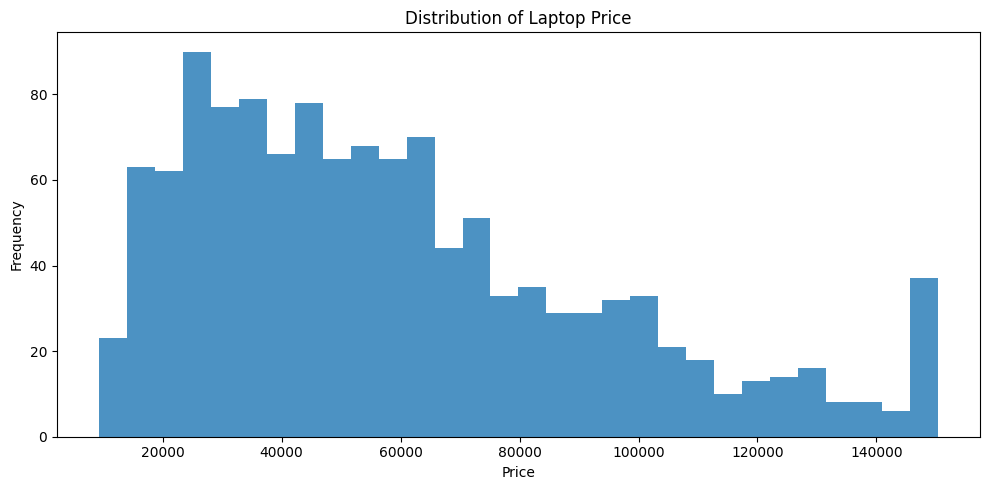

Price skewness: 0.8556


,price
count,"1,243.0000"
mean,"59,737.1652"
std,"34,344.3636"
min,"9,270.7200"
25%,"32,650.2504"
50%,"52,693.9200"
75%,"79,733.5200"
max,"150,358.4244"


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["price"], bins=30, alpha=0.8)
ax.set_title("Distribution of Laptop Price")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Price skewness:", round(df["price"].skew(), 4))
display(df["price"].describe().to_frame("price"))

### Target-distribution observation

The target is **right-skewed**, with a skewness of approximately **0.856**. Most observations lie below the upper end of the price range, while a smaller number of relatively expensive laptops extend the right tail.

This matters for the later regression results because a small number of high-price observations can contribute disproportionately to squared error. That is one reason to examine both RMSE and MAE instead of relying on a single error metric.

## 5. Feature distribution analysis

The predictors include a mixture of continuous or multi-valued measurements and binary encoded indicators. The distributions are therefore displayed in two groups.

For the continuous variables, the plots show the empirical spread of quantities such as screen size, RAM, weight, resolution, storage, and PPI. For binary variables, the bars show how frequently each encoded condition occurs in the dataset.

Looking at these distributions helps identify concentration, skewness, sparse categories, and large differences in scale before the regression models are fitted.

In [5]:
feature_columns = [c for c in df.columns if c != "price"]

binary_features = []
continuous_features = []

for col in feature_columns:
    unique_values = df[col].nunique(dropna=False)
    if unique_values <= 2:
        binary_features.append(col)
    else:
        continuous_features.append(col)

print("Continuous / multi-valued features:", len(continuous_features))
print(continuous_features)

print("\nBinary features:", len(binary_features))
print(binary_features)

Continuous / multi-valued features: 7
['inches', 'ram', 'weight', 'res_width', 'res_height', 'storage_gb', 'ppi']

Binary features: 35
['is_ips', 'is_touchscreen', 'has_ssd', 'has_hdd', 'company_Apple', 'company_Asus', 'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google', 'company_Hp', 'company_Huawei', 'company_Lenovo', 'company_Lg', 'company_Mediacom', 'company_Microsoft', 'company_Msi', 'company_Razer', 'company_Samsung', 'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'typename_Gaming', 'typename_Netbook', 'typename_Notebook', 'typename_Ultrabook', 'typename_Workstation', 'opsys_Chrome Os', 'opsys_Linux', 'opsys_Mac Os X', 'opsys_Macos', 'opsys_No Os', 'opsys_Windows 10', 'opsys_Windows 10 S', 'opsys_Windows 7']


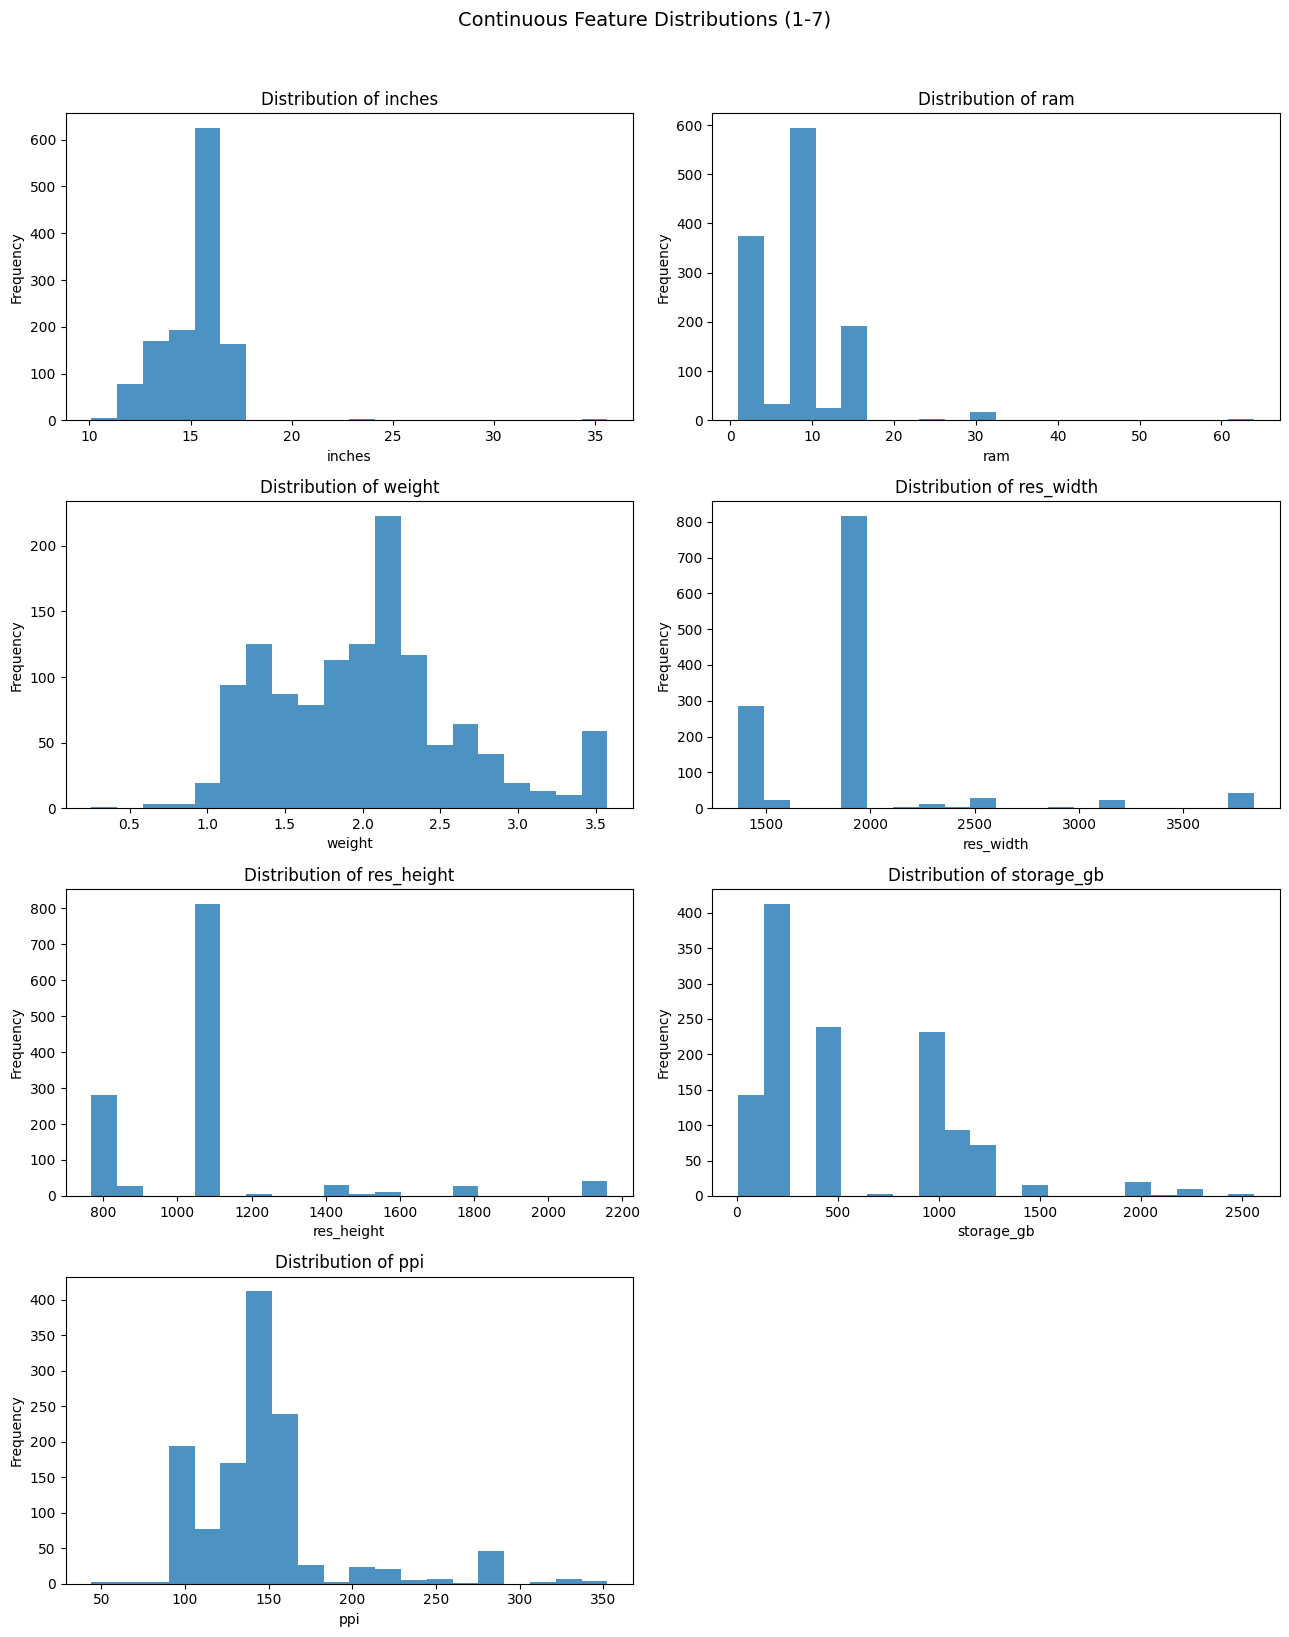

In [6]:
# Continuous feature distributions
group_size = 8

for start in range(0, len(continuous_features), group_size):
    group = continuous_features[start:start + group_size]

    ncols = 2
    nrows = int(np.ceil(len(group) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, group):
        ax.hist(df[col], bins=20, alpha=0.8)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    for ax in axes[len(group):]:
        ax.axis("off")

    fig.suptitle(
        f"Continuous Feature Distributions ({start + 1}-{start + len(group)})",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

### Continuous-feature distribution observations

The continuous predictors are not all distributed in the same way. `weight` is comparatively balanced, while variables such as **RAM, screen size, resolution, storage, and PPI are right-skewed**. RAM, for example, has a skewness of approximately **3.63**, and PPI has a skewness of about **1.99**.

Several variables also take values from a relatively small set of common configurations rather than behaving like perfectly continuous measurements. That pattern is expected for laptop specifications and means a large part of the dataset is concentrated around a finite set of market configurations.

These distributions help explain why standardisation is useful and why a flexible functional form may capture relationships that a single straight-line effect cannot.

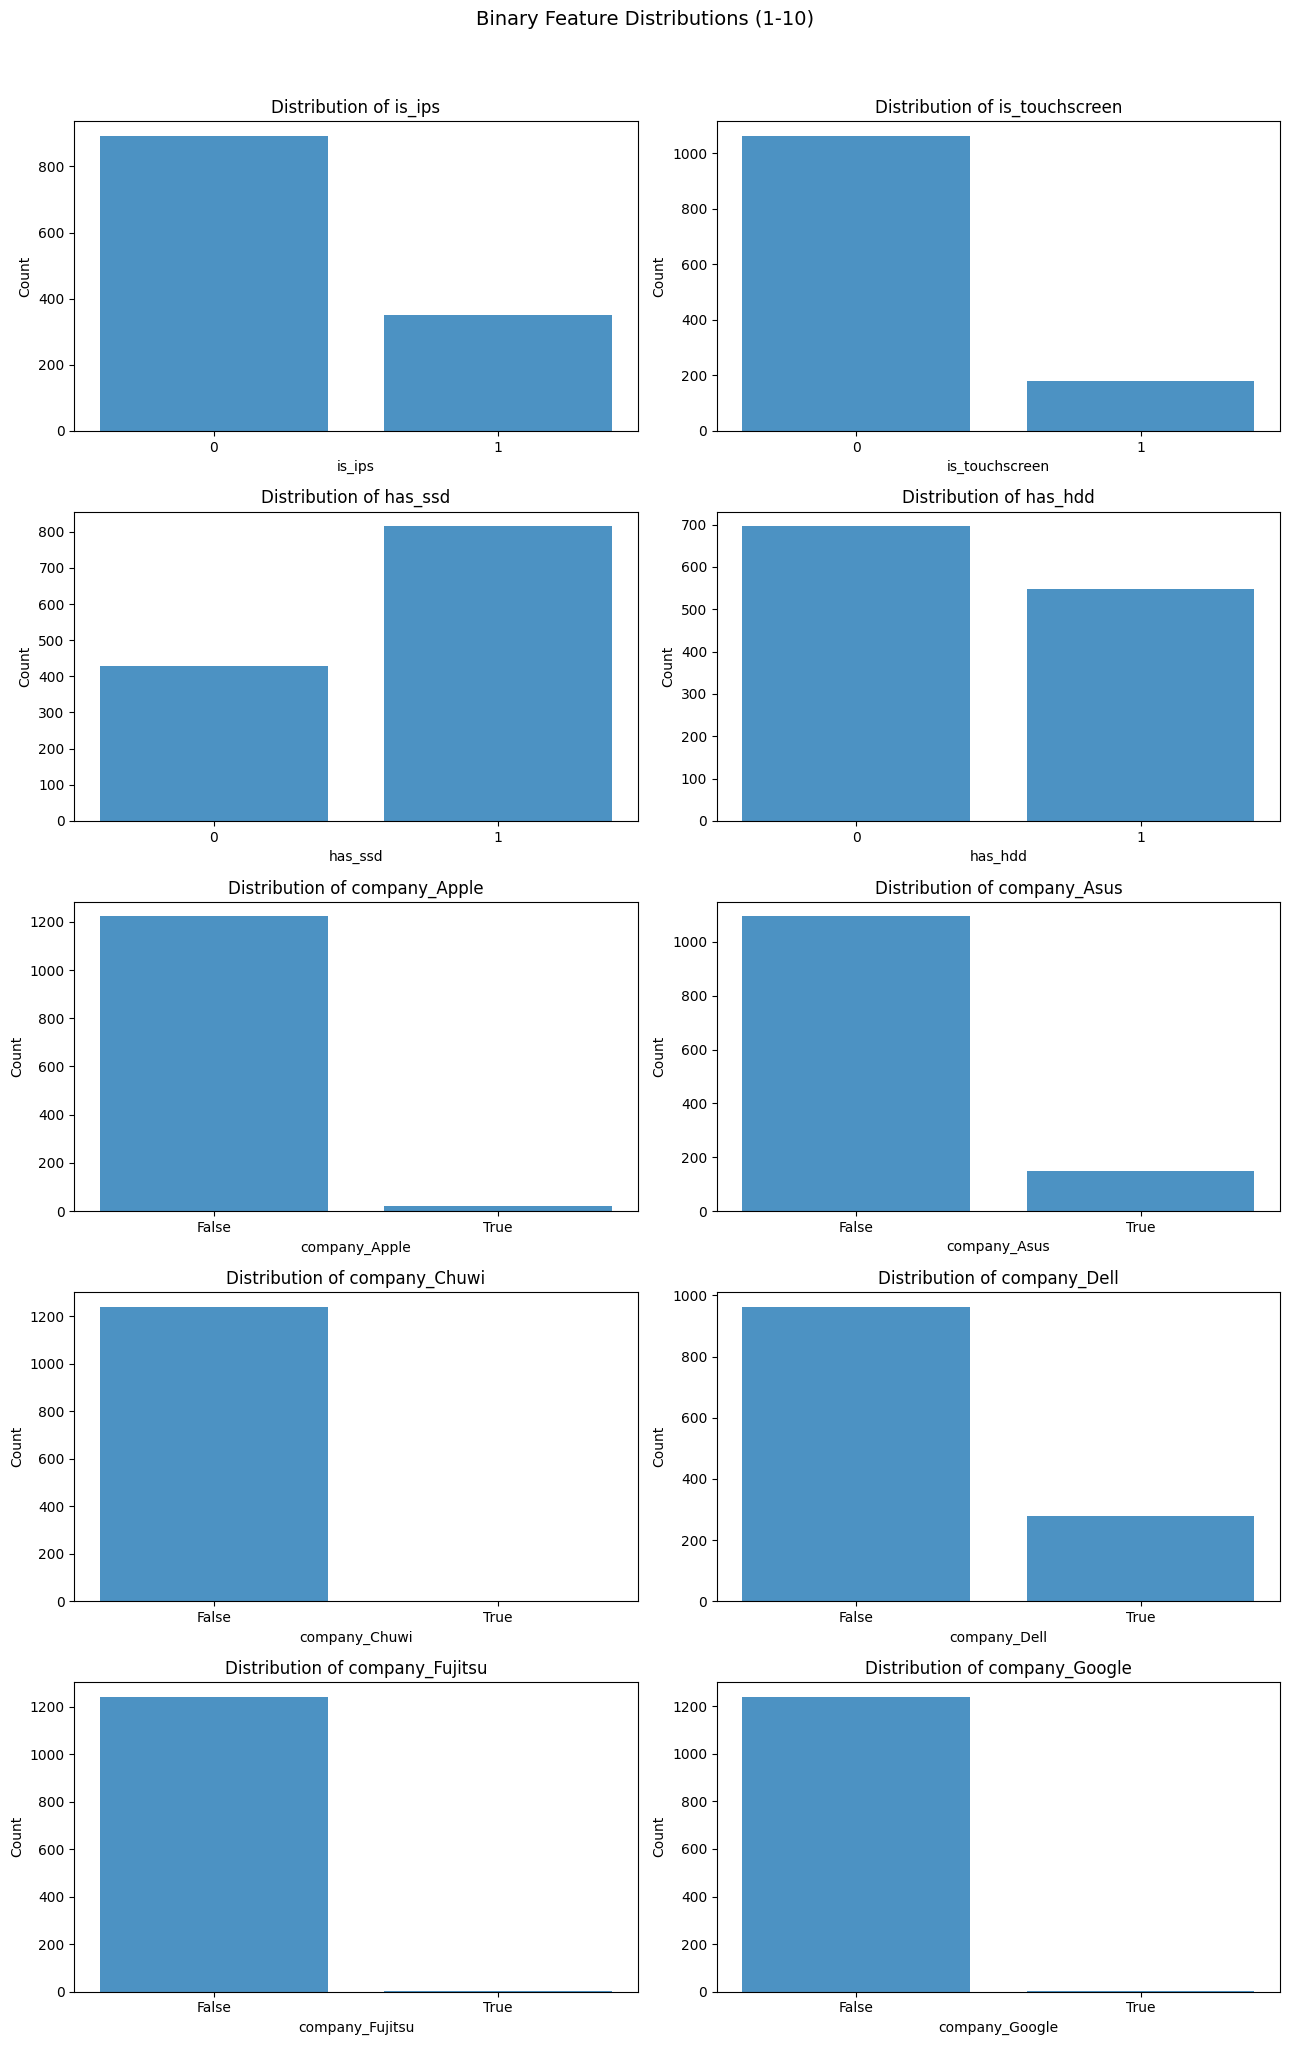

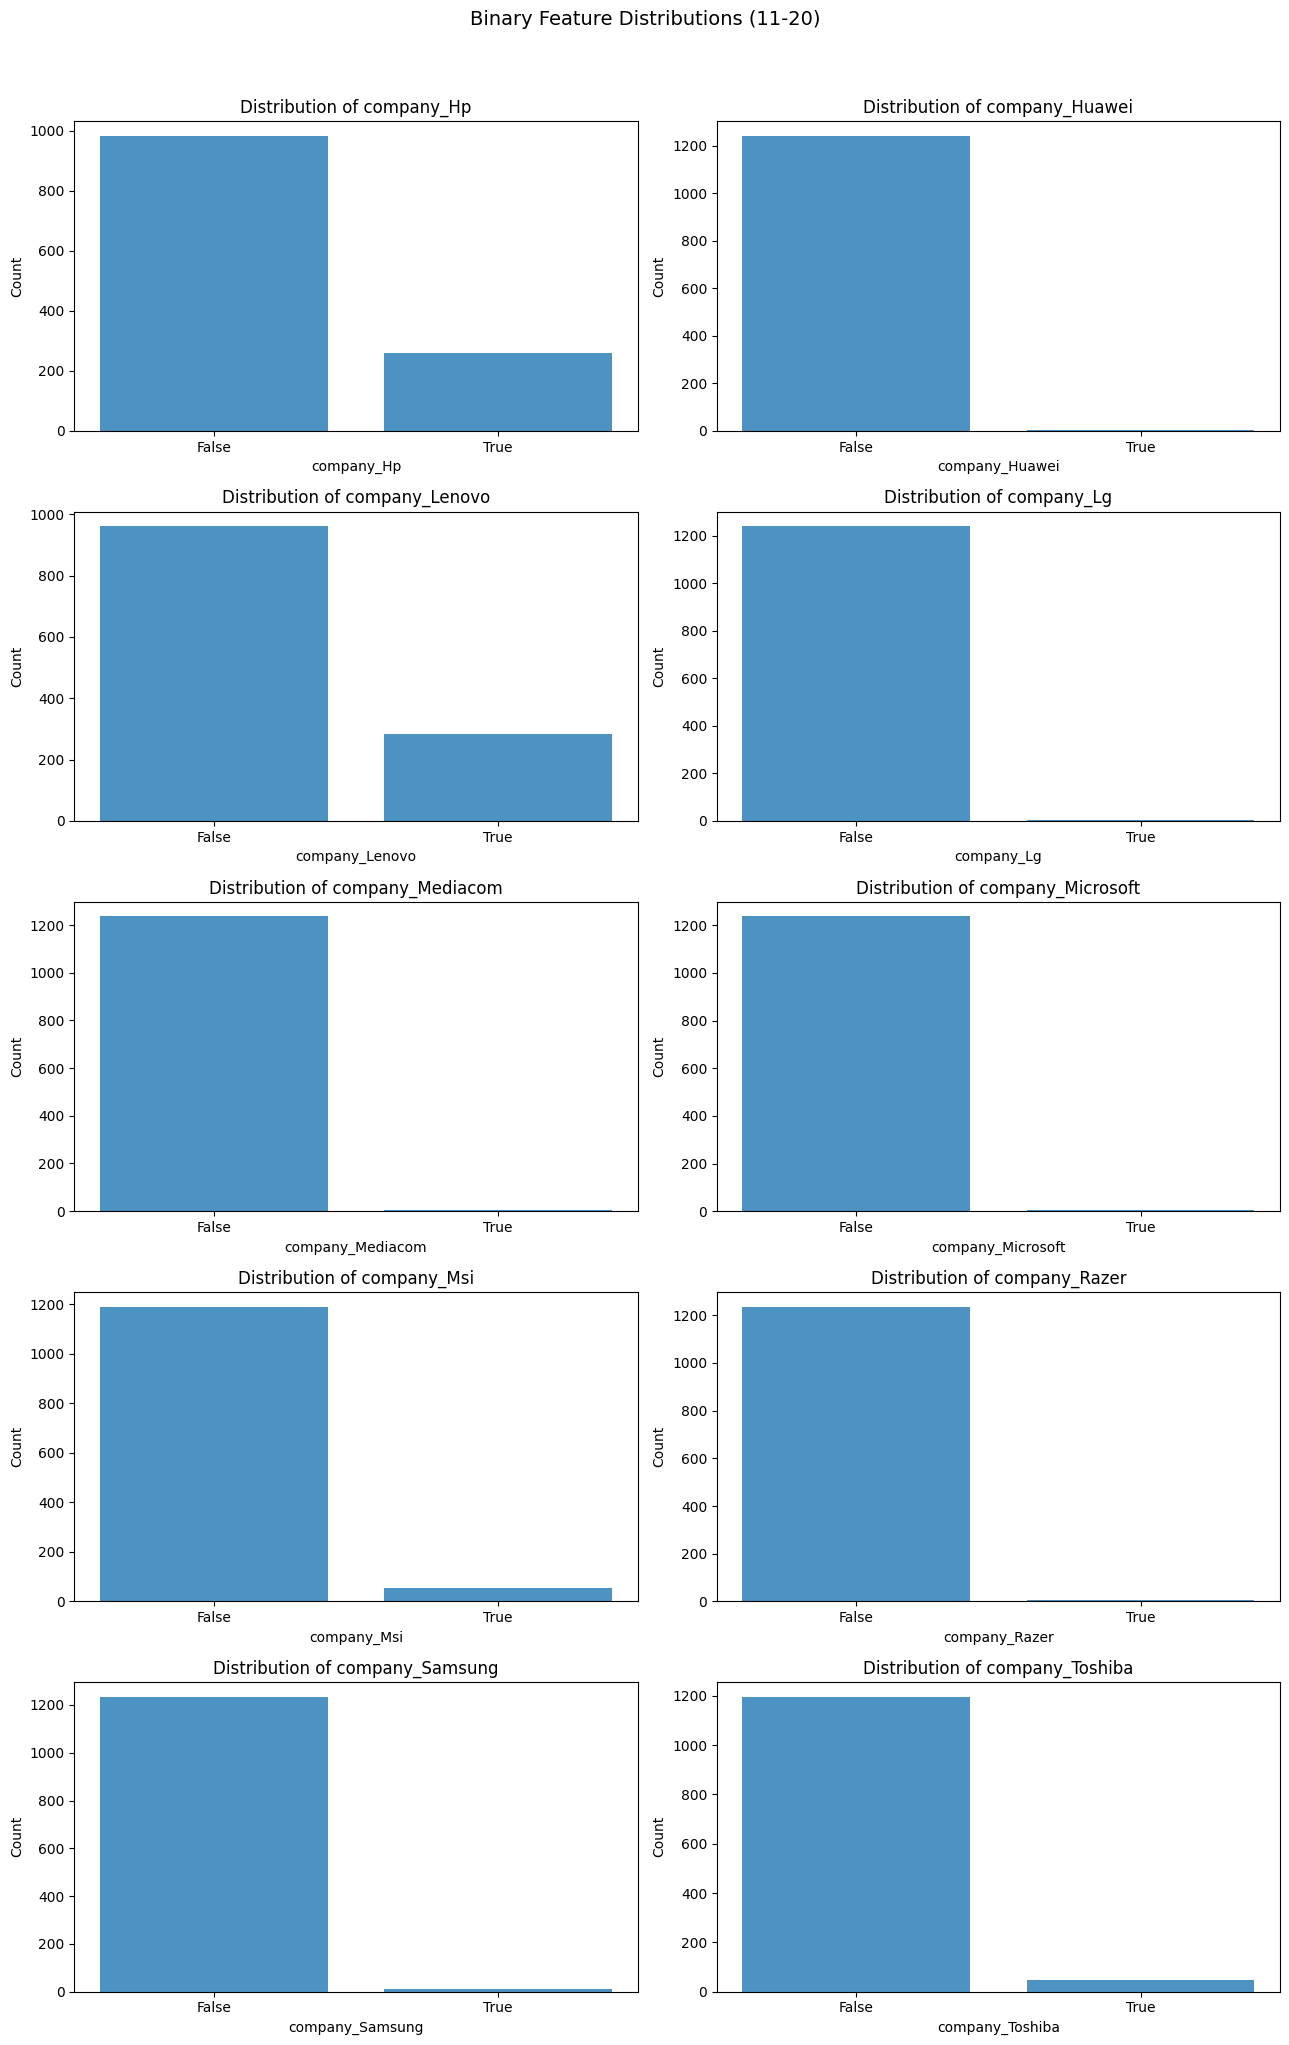

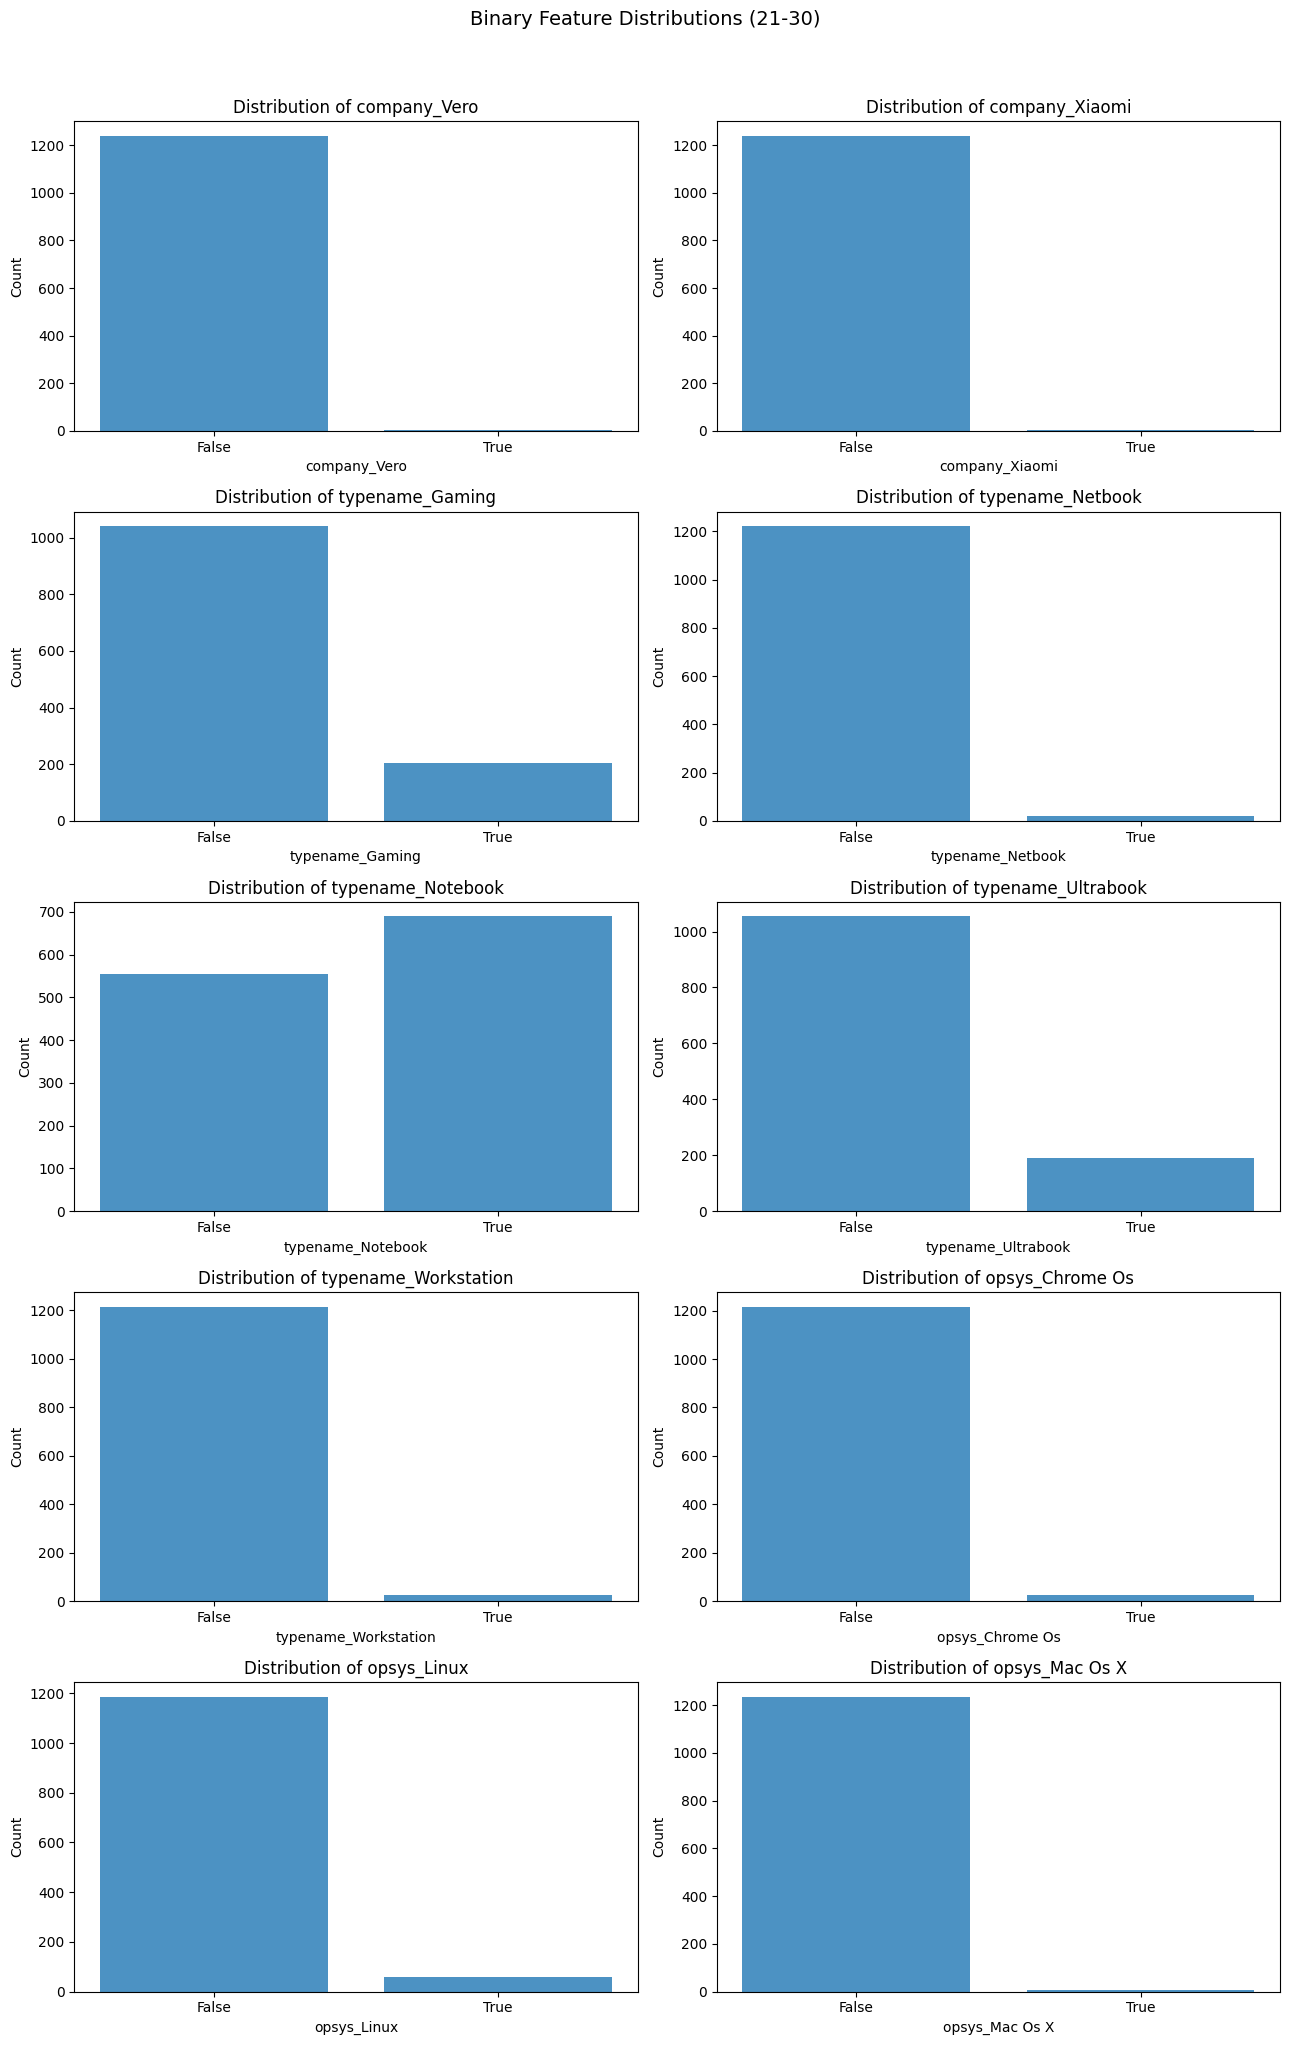

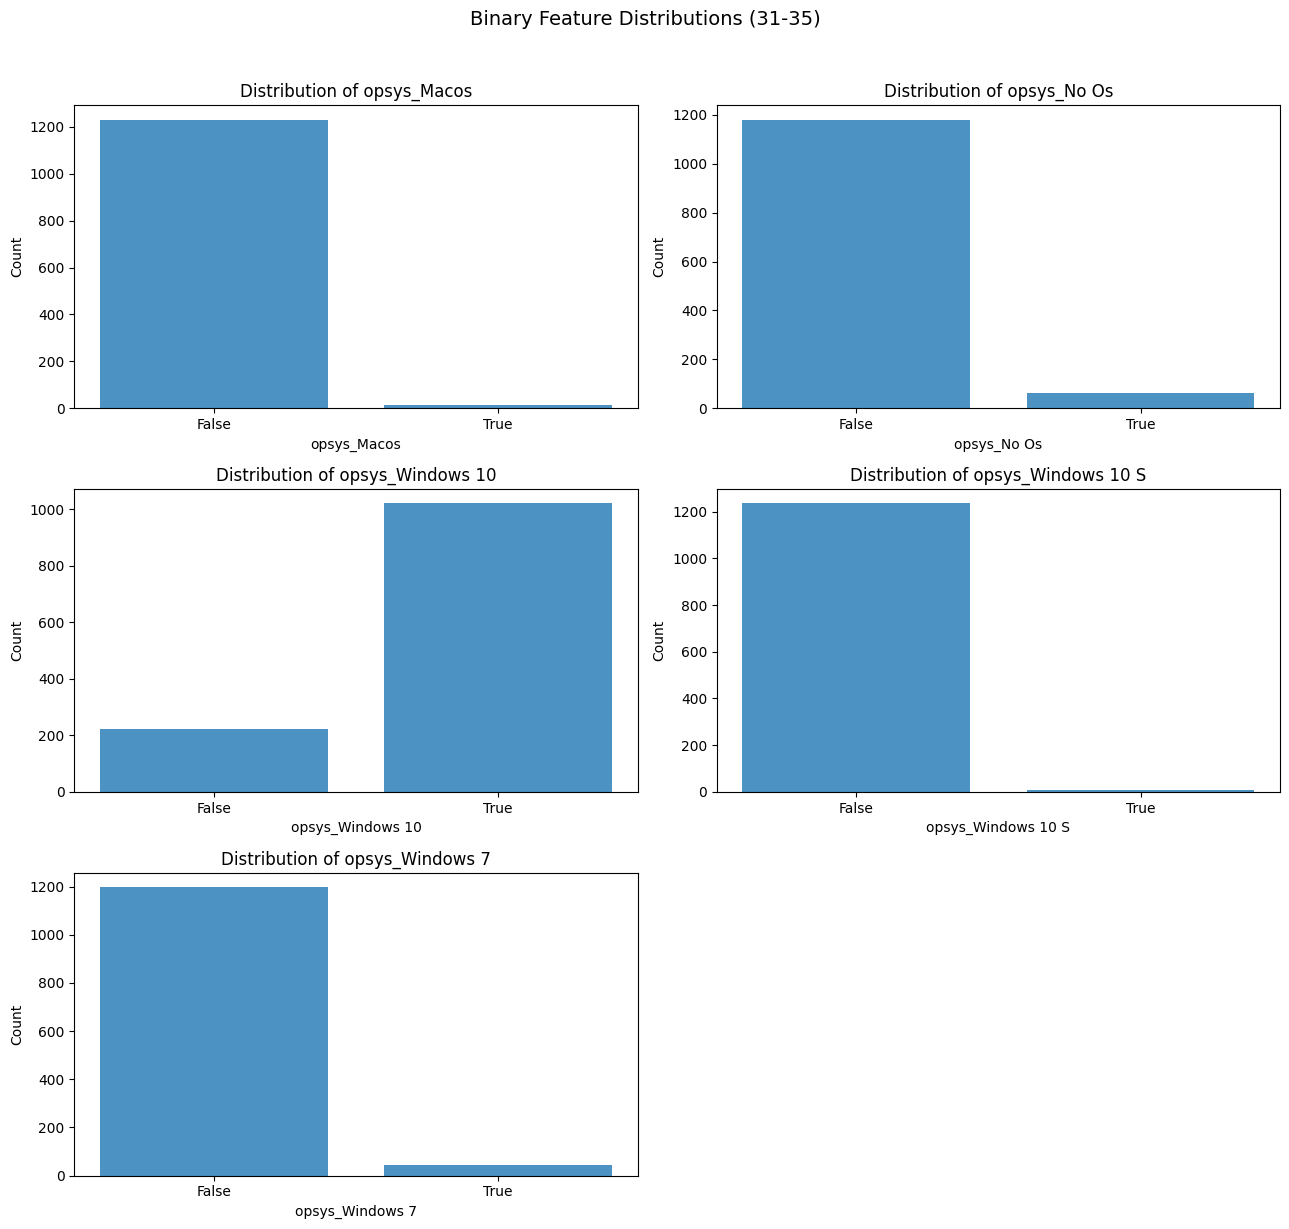

In [7]:
# Binary feature distributions
group_size = 10

for start in range(0, len(binary_features), group_size):
    group = binary_features[start:start + group_size]

    ncols = 2
    nrows = int(np.ceil(len(group) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, group):
        counts = df[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, alpha=0.8)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")

    for ax in axes[len(group):]:
        ax.axis("off")

    fig.suptitle(
        f"Binary Feature Distributions ({start + 1}-{start + len(group)})",
        fontsize=14,
        y=1.02
    )
    plt.tight_layout()
    plt.show()

### Binary-feature distribution observations

The binary indicators are highly imbalanced rather than equally represented. For example, `opsys_Windows 10` is present in about **82.1%** of observations, `has_ssd` in **65.6%**, and `typename_Notebook` in **55.4%**. In contrast, several manufacturer indicators occur in well below 1% of rows.

This imbalance is important when interpreting coefficients and correlations for one-hot variables. A rare category can still have a meaningful fitted coefficient, but that coefficient is supported by relatively few observations and should therefore be interpreted alongside the model's overall behaviour rather than in isolation.

## 6. Correlation analysis

The correlation matrix provides a first view of the linear associations between the numerical predictors and laptop price. It is useful for understanding which features may contribute strongly to a linear model and for spotting groups of predictors that may contain overlapping information.

A correlation coefficient describes linear association, not causation, and a low Pearson correlation does not rule out a useful nonlinear relationship. This distinction becomes important when Polynomial Regression is introduced later.

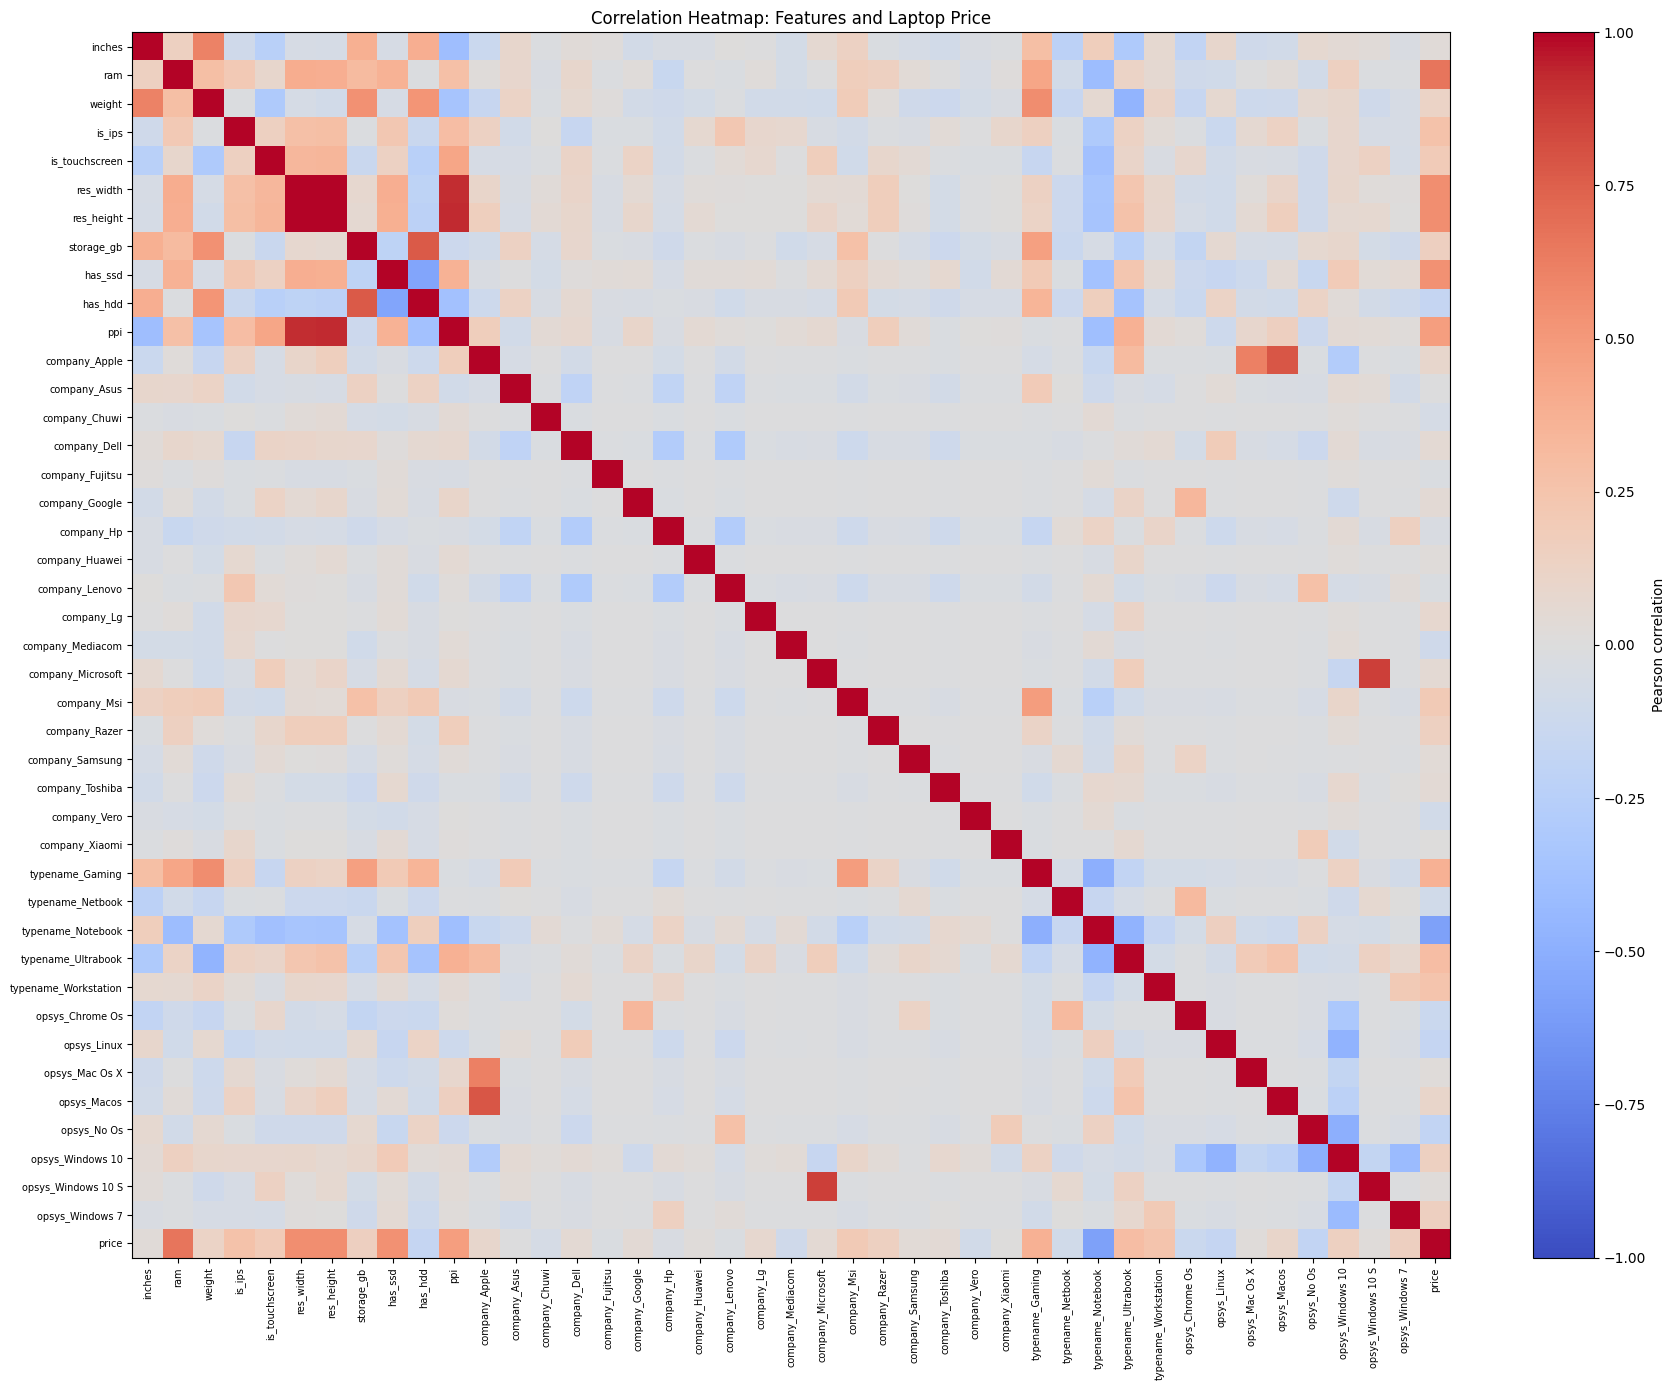

In [8]:
corr_matrix = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(18, 14))
image = ax.imshow(corr_matrix.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.index, fontsize=7)
ax.set_title("Correlation Heatmap: Features and Laptop Price")

fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

### Heatmap observation

The heatmap reinforces the numerical ranking: **RAM, screen resolution, SSD presence, and PPI** show noticeably positive association with price, while some laptop-type and operating-system indicators have negative association.

The heatmap also shows why regularisation is worth testing. Several hardware and categorical indicators can carry overlapping information about the type of laptop, so an unregularised model may distribute their effects in a less stable way. Ridge and ElasticNet provide controlled coefficient shrinkage for this situation.

In [9]:
price_correlations = (
    df.drop(columns=["price"])
      .corrwith(df["price"])
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Features ranked by absolute Pearson correlation with price:")
display(price_correlations.to_frame("corr_with_price").head(15))

Features ranked by absolute Pearson correlation with price:


,corr_with_price
ram,0.6591
typename_Notebook,-0.5842
res_width,0.5497
res_height,0.5473
has_ssd,0.5330
ppi,0.4740
typename_Gaming,0.3748
typename_Ultrabook,0.2907
is_ips,0.2653
typename_Workstation,0.2422


### Correlation interpretation

The strongest positive correlations with `price` in the prepared dataset are:

- **RAM:** approximately **0.659**
- **res_width:** approximately **0.550**
- **res_height:** approximately **0.547**
- **has_ssd:** approximately **0.533**
- **PPI:** approximately **0.474**

The strongest negative association is `typename_Notebook`, at approximately **-0.584**. Because the encoded variables represent categories rather than continuous measurements, these correlations should be interpreted as differences in price associated with the presence of a category indicator, not as continuous physical relationships.

The relatively strong correlation between RAM and price provides a useful reason to inspect the RAM-price scatter plot and later test whether allowing curvature improves upon a purely linear specification.

## 7. Feature-target relationship plots

Two continuous variables, **RAM** and **PPI**, are examined against price. RAM represents memory capacity, while PPI represents display pixel density derived during preprocessing.

These plots complement the correlation analysis because they show the actual point cloud rather than reducing the relationship to a single coefficient. We can therefore look for approximate linearity, curvature, clusters, and changes in spread.

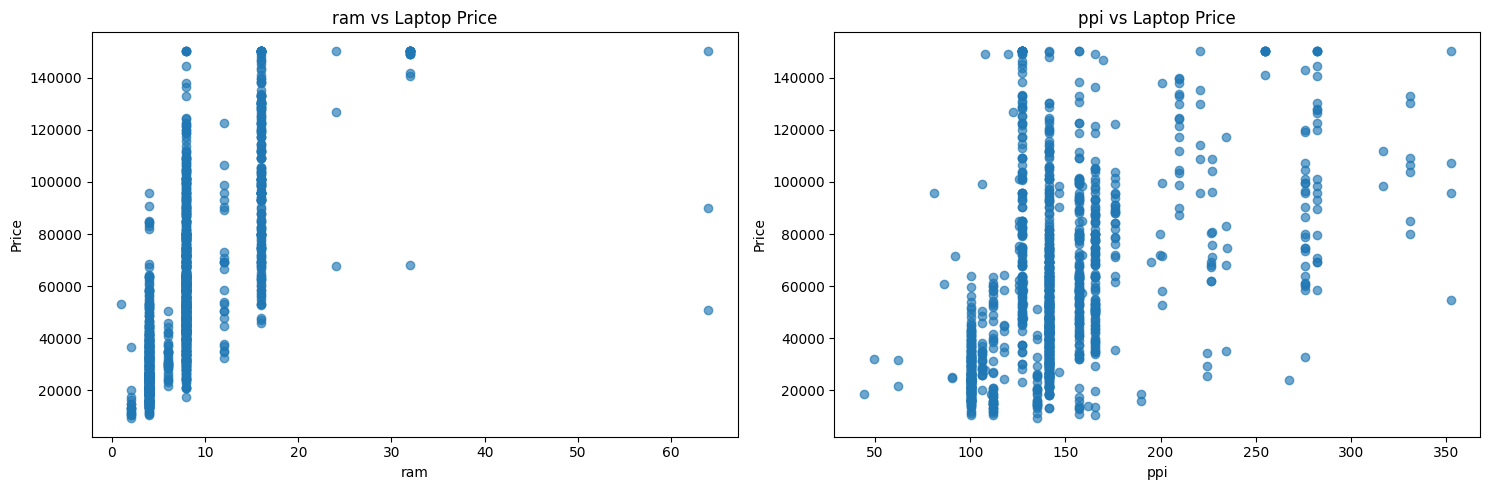

In [10]:
relationship_features = ["ram", "ppi"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, feature in zip(axes, relationship_features):
    ax.scatter(df[feature], df["price"], alpha=0.65)
    ax.set_title(f"{feature} vs Laptop Price")
    ax.set_xlabel(feature)
    ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

### Scatter-plot observation

The RAM scatter plot shows a clear upward trend, but the points form several vertical bands because RAM is recorded in a limited set of standard capacities. Within a single RAM value, price still varies substantially, showing that other specifications and categories contribute important additional information.

The PPI scatter plot is more diffuse. Higher PPI values are generally associated with higher prices, but the relationship is weaker than the RAM relationship and the point cloud has substantial spread. This supports using multiple predictors rather than treating any single display or memory feature as sufficient for price prediction.

### Relationship-plot observations

**RAM vs Price:** RAM has a correlation of approximately **0.659** with price, making it the strongest single continuous predictor in this dataset by Pearson correlation. The relationship is clearly positive, but the observations do not collapse onto a single straight line. Different laptop categories and configurations can have very different prices even at similar RAM values.

**PPI vs Price:** PPI has a weaker but still positive correlation of approximately **0.474**. The relationship is more dispersed than the RAM relationship, indicating that display pixel density alone does not explain a large portion of the variation in price.

Together, these plots suggest that linear relationships contain substantial predictive signal, but they also leave room for nonlinear effects and interactions among laptop specifications.

## 8. Separate predictors and target

The regression target is:

$$
y = price
$$

All remaining columns form the predictor matrix:

$$
X = [x_1,x_2,\ldots,x_p]
$$

The boolean indicator columns are converted to `0` and `1` so every predictor has an explicit numerical representation before it enters the estimators. No additional target-derived feature is created at this stage.

In [11]:
X = df.drop(columns=["price"]).copy()
y = df["price"].copy()

bool_columns = X.select_dtypes(include=["bool"]).columns.tolist()
if bool_columns:
    X[bool_columns] = X[bool_columns].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of boolean columns converted:", len(bool_columns))

display(X.head())

X shape: (1243, 42)
y shape: (1243,)
Number of boolean columns converted: 31


,inches,ram,weight,is_ips,is_touchscreen,res_width,res_height,storage_gb,has_ssd,has_hdd,ppi,company_Apple,company_Asus,company_Chuwi,company_Dell,company_Fujitsu,company_Google,company_Hp,company_Huawei,company_Lenovo,company_Lg,company_Mediacom,company_Microsoft,company_Msi,company_Razer,company_Samsung,company_Toshiba,company_Vero,company_Xiaomi,typename_Gaming,typename_Netbook,typename_Notebook,typename_Ultrabook,typename_Workstation,opsys_Chrome Os,opsys_Linux,opsys_Mac Os X,opsys_Macos,opsys_No Os,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7
0,13.3000,8.0000,1.3700,1,0,2560,1600,128.0000,1,0,226.9830,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
1,13.3000,8.0000,1.3400,0,0,1440,900,128.0000,0,0,127.6779,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
2,15.6000,8.0000,1.8600,0,0,1920,1080,256.0000,1,0,141.2120,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
3,15.4000,16.0000,1.8300,1,0,2880,1800,512.0000,1,0,220.5346,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0
4,13.3000,8.0000,1.3700,1,0,2560,1600,256.0000,1,0,226.9830,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0


## 9. Reproducible train/test split

The same train/test partition is reused for all five algorithms so the metric differences come from the modelling methods rather than from different test observations. The split uses **80% of the data for training and 20% for testing**.

Because `price` is continuous, ordinary class-based stratification is not applicable. Instead, the continuous target is divided into five quantile bins only for the purpose of constructing approximately balanced train and test partitions. The original continuous values remain unchanged as the regression target.

In [12]:
target_bins = pd.qcut(y, q=5, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

split_summary = pd.DataFrame({
    "Train": y_train.describe(),
    "Test": y_test.describe(),
    "Full": y.describe()
})
display(split_summary)

Training samples: 994
Test samples: 249


,Train,Test,Full
count,994.0000,249.0000,"1,243.0000"
mean,"59,807.8711","59,454.9097","59,737.1652"
std,"34,354.5321","34,371.4183","34,344.3636"
min,"10,602.7200","9,270.7200","9,270.7200"
25%,"32,673.9600","32,447.5200","32,650.2504"
50%,"52,693.9200","52,480.8000","52,693.9200"
75%,"79,813.4400","79,653.6000","79,733.5200"
max,"150,358.4244","150,358.4244","150,358.4244"


## 10. Leakage-safe scaling strategy

Scaling is particularly important for Ridge, Lasso, and ElasticNet because their regularisation penalties act directly on coefficient magnitudes. A predictor measured in a much larger numerical unit could otherwise influence the penalty differently from a predictor with a smaller scale.

The `Pipeline` objects place `StandardScaler` before the regression estimator. Consequently, the mean and standard deviation used for standardisation are learned from the training portion only, and the same transformation is then applied to validation or test observations. The same idea remains valid inside cross-validation because each fold fits its own scaler on its own training subset.

The standardisation transformation is

$$
z_j = \frac{x_j-\mu_j}{\sigma_j}
$$

where $\mu_j$ and $\sigma_j$ are calculated from the relevant training data.

In [13]:
def regression_metrics(y_true, y_pred):
    # Return the mandatory regression metrics in one consistent dictionary.
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    # Fit, predict, and calculate the same metrics for every model.
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = regression_metrics(y_test, predictions)
    metrics["Algorithm"] = name

    return model, predictions, metrics

print("Evaluation helpers ready.")

Evaluation helpers ready.


# 11. Algorithm 1 - Linear Regression

### How Linear Regression works

Linear Regression models the expected target as a weighted sum of the predictors. In vector form, the prediction is

$$
\hat{y}_i = \beta_0 + \sum_{j=1}^{p}\beta_j x_{ij}
$$

where $\beta_0$ is the intercept and $\beta_j$ is the coefficient associated with feature $j$.

The coefficients are estimated by minimising the sum of squared residuals:

$$
\min_{\beta_0,\beta}\;\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2
$$

The model is a useful baseline because it is simple and interpretable. A positive coefficient indicates that increasing the corresponding standardised predictor is associated with a higher predicted price while holding the other predictors fixed; a negative coefficient indicates the opposite direction.

Because the predictors are standardised inside the pipeline, the coefficient magnitudes are on a common scale, which makes relative coefficient size easier to inspect later.

In [14]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model, linear_pred, linear_metrics = evaluate_model(
    "Linear Regression",
    linear_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([linear_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6643,"19,874.2983","13,925.1129",Linear Regression


### Linear Regression result and interpretation

The baseline Linear Regression model achieves **$R^2=0.6643$**, with **RMSE = 19,874.30** and **MAE = 13,925.11** on the held-out test set.

An $R^2$ of 0.6643 means that, on this test split, the fitted linear relationship explains about **66.43% of the variance in laptop price relative to a constant-mean predictor**. The RMSE is larger than the MAE, which is expected because RMSE gives greater weight to larger errors.

This result gives us a reference point. The next models will test whether constraining coefficient magnitudes with regularisation can improve generalisation or produce a more stable representation.

# 12. Algorithm 2 - Ridge Regression

### How Ridge Regression works

Ridge Regression extends ordinary least squares by adding an **L2 penalty** on the coefficients. Its objective is

$$
\min_{\beta_0,\beta}\left\{\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2+\alpha\sum_{j=1}^{p}\beta_j^2\right\}
$$

The parameter $\alpha\ge 0$ controls the strength of the penalty. When $\alpha=0$, the objective reduces to ordinary least squares. As $\alpha$ increases, the fitted coefficients are pushed closer to zero.

The important distinction from feature selection is that Ridge generally **shrinks coefficients without forcing them exactly to zero**. This is especially useful when several predictors carry related information, because spreading the effect across correlated variables can be more stable than allowing an unregularised model to assign large opposing coefficients.

In [15]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model, ridge_pred, ridge_metrics = evaluate_model(
    "Ridge Regression",
    ridge_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([ridge_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6652,"19,848.1252","13,895.0261",Ridge Regression


### Ridge Regression result and interpretation

With the baseline setting $\alpha=1$, Ridge achieves **$R^2=0.6652$**, **RMSE = 19,848.13**, and **MAE = 13,895.03**.

Relative to Linear Regression, the change is small but positive on this test split: $R^2$ increases from **0.6643 to 0.6652**, while both RMSE and MAE decrease slightly. This suggests that a small amount of coefficient shrinkage helps the model generalise marginally better than the unregularised baseline.

The improvement is deliberately modest. Regularisation is not automatically beneficial; its value depends on the degree of coefficient instability and redundancy present in the feature set. The later tuning step tests stronger values of $\alpha$ rather than assuming that 1.0 is optimal.

In [36]:
ridge_coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": ridge_model.named_steps["model"].coef_
})

ridge_coefficient_table["Absolute_Coefficient"] = (
    ridge_coefficient_table["Coefficient"].abs()
)

ridge_coefficient_table = ridge_coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(ridge_coefficient_table)

,Feature,Coefficient,Absolute_Coefficient
1,ram,"11,792.8490","11,792.8490"
5,res_width,"9,956.8051","9,956.8051"
31,typename_Notebook,"-8,194.4990","8,194.4990"
8,has_ssd,"7,495.9728","7,495.9728"
41,opsys_Windows 7,"5,303.8378","5,303.8378"
33,typename_Workstation,"4,699.7198","4,699.7198"
17,company_Hp,"4,236.0346","4,236.0346"
6,res_height,"-4,148.4488","4,148.4488"
19,company_Lenovo,"3,329.2621","3,329.2621"
26,company_Toshiba,"3,229.8857","3,229.8857"


# 13. Algorithm 3 - Lasso Regression

### How Lasso Regression works

Lasso Regression uses an **L1 penalty**, which penalises the absolute value of each coefficient:

$$
\min_{\beta_0,\beta}\left\{\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2+\alpha\sum_{j=1}^{p}|\beta_j|\right\}
$$

The absolute-value penalty creates a key property: some coefficients can be driven **exactly to zero**. Those zero coefficients mean the corresponding predictors do not contribute to the final fitted model at that regularisation strength.

Lasso therefore performs two jobs simultaneously: it predicts the target and encourages a sparse coefficient vector. The trade-off is controlled by $\alpha$. A small $\alpha$ allows more coefficients to remain active, while a larger $\alpha$ exerts stronger pressure toward zero.

In [17]:
lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=100.0, max_iter=20000))
])

lasso_model, lasso_pred, lasso_metrics = evaluate_model(
    "Lasso Regression",
    lasso_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([lasso_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6644,"19,873.1352","13,946.8751",Lasso Regression


In [37]:
lasso_coefficients = pd.Series(
    lasso_model.named_steps["model"].coef_,
    index=X_train.columns
)

zero_count = int((lasso_coefficients == 0).sum())
non_zero_count = int((lasso_coefficients != 0).sum())

print("Lasso coefficients equal to zero:", zero_count)
print("Lasso coefficients retained:", non_zero_count)



Lasso coefficients equal to zero: 6
Lasso coefficients retained: 36


### Lasso coefficient interpretation

The coefficient table shows which standardised predictors retain the largest absolute effects after the L1 penalty is applied. In this fitted model, **RAM** has the largest coefficient magnitude, followed by `typename_Notebook`, `has_ssd`, and `res_width`.

The presence of exactly **6 zero coefficients** is the clearest sign of Lasso's sparsity mechanism. The model has removed some predictors from the linear equation entirely at the selected regularisation strength, while retaining 36 predictors with non-zero coefficients.

### Lasso result and sparsity interpretation

The baseline Lasso model reaches **$R^2=0.6644$**, **RMSE = 19,873.14**, and **MAE = 13,946.88**. Its test performance is almost identical to Linear Regression: the difference in $R^2$ is only about **0.0001**.

The coefficient inspection shows **6 coefficients exactly equal to zero** and **36 retained coefficients**. This demonstrates the sparsity effect of the L1 penalty on this dataset.

The strongest retained coefficient magnitude belongs to `ram`, followed by variables such as `typename_Notebook`, `has_ssd`, and `res_width`. Importantly, the existence of zero coefficients does not by itself imply better prediction. Here the predictive metrics remain very close to the ordinary linear baseline, so the main observed benefit is the simpler sparse representation rather than a large increase in test accuracy.

In [38]:
lasso_coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_model.named_steps["model"].coef_
})

lasso_coefficient_table["Absolute_Coefficient"] = (
    lasso_coefficient_table["Coefficient"].abs()
)

lasso_coefficient_table = lasso_coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

display(lasso_coefficient_table)

,Feature,Coefficient,Absolute_Coefficient
1,ram,"11,878.5592","11,878.5592"
31,typename_Notebook,"-7,705.6914","7,705.6914"
8,has_ssd,"7,417.6387","7,417.6387"
5,res_width,"6,704.3255","6,704.3255"
33,typename_Workstation,"4,810.0094","4,810.0094"
41,opsys_Windows 7,"4,599.0307","4,599.0307"
17,company_Hp,"2,990.4710","2,990.4710"
26,company_Toshiba,"2,594.9189","2,594.9189"
32,typename_Ultrabook,"2,174.5572","2,174.5572"
24,company_Razer,"2,069.1688","2,069.1688"


# 14. Algorithm 4 - ElasticNet Regression

### How ElasticNet works

ElasticNet combines the L1 and L2 penalties used by Lasso and Ridge. Its objective can be written as

$$
\min_{\beta_0,\beta}\left\{\sum_{i=1}^{n}\left(y_i-\beta_0-\mathbf{x}_i^T\beta\right)^2+\alpha\left[\rho\sum_{j=1}^{p}|\beta_j|+(1-\rho)\sum_{j=1}^{p}\beta_j^2\right]\right\}
$$

where $\alpha$ controls the overall regularisation strength and $\rho$ (the `l1_ratio` in scikit-learn) controls the mixture between L1 and L2 regularisation.

- $\rho=1$ gives a Lasso-like penalty.
- $\rho=0$ gives a Ridge-like penalty.
- Intermediate values combine coefficient shrinkage with the possibility of sparsity.

This combination is useful when predictors are numerous or correlated and we want some of the feature-selection behaviour of Lasso without discarding the stabilising effect of Ridge.

In [20]:
elasticnet_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=20000
    ))
])

elasticnet_model, elasticnet_pred, elasticnet_metrics = evaluate_model(
    "ElasticNet Regression",
    elasticnet_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([elasticnet_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.6694,"19,724.3678","13,995.9798",ElasticNet Regression


### ElasticNet result and interpretation

With the baseline setting $\alpha=0.1$ and `l1_ratio=0.5`, ElasticNet obtains **$R^2=0.6694$**, **RMSE = 19,724.37**, and **MAE = 13,995.98**.

Among the four baseline linear-family models, this is the highest test-set $R^2$. The result suggests that combining L1 and L2 regularisation gives a small predictive advantage on this split. The gain is not large, so tuning both regularisation strength and the L1/L2 mixture is still necessary before treating this configuration as the final ElasticNet model.

# 15. Algorithm 5 - Polynomial Regression

### How Polynomial Regression works

Polynomial Regression keeps a linear regression estimator but expands selected input variables into powers and interactions. For one feature $x$, a degree-$d$ polynomial model has the form

$$
\hat{y}=\beta_0+\beta_1x+\beta_2x^2+\cdots+\beta_d x^d
$$

The model is still **linear in the coefficients** $\beta_0,\beta_1,\ldots,\beta_d$; the nonlinearity comes from the transformed features $x^2,x^3,\ldots$.

In this notebook, polynomial expansion is deliberately restricted to **RAM**. Expanding every encoded categorical column would create a much larger feature space containing many redundant dummy powers and interactions. Restricting the expansion keeps the experiment interpretable while testing whether the strongest continuous predictor benefits from a nonlinear relationship.

The polynomial degree is selected using cross-validation on the training data only.

In [21]:
poly_feature = ["ram"]
other_features = [c for c in X_train.columns if c not in poly_feature]

def make_polynomial_pipeline(degree):
    # Polynomial expansion is restricted to RAM to control dimensionality.
    preprocessing = ColumnTransformer(
        transformers=[
            (
                "ram_polynomial",
                Pipeline([
                    ("poly", PolynomialFeatures(
                        degree=degree,
                        include_bias=False
                    )),
                    ("scaler", StandardScaler())
                ]),
                poly_feature
            ),
            (
                "other_features",
                StandardScaler(),
                other_features
            )
        ],
        remainder="drop"
    )

    return Pipeline([
        ("preprocessing", preprocessing),
        ("model", LinearRegression())
    ])

print("Polynomial model design prepared.")

Polynomial model design prepared.


## 16. Compare polynomial degrees

The polynomial experiment compares degrees **1, 2, 3, and 4**. Degree 1 corresponds to a linear relationship in RAM, while higher degrees allow progressively more curvature.

The comparison uses 5-fold cross-validation on the training data. For each candidate degree, the mean $R^2$ summarises predictive performance across the folds and the standard deviation shows how much that performance changes from fold to fold.

The test set is not used to choose the degree, so it remains available for the final generalisation check.

In [22]:
polynomial_degree_results = []

for degree in [1, 2, 3, 4]:
    candidate = make_polynomial_pipeline(degree)

    cv_scores = cross_val_score(
        candidate,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    polynomial_degree_results.append({
        "Degree": degree,
        "Mean CV R2": cv_scores.mean(),
        "Std CV R2": cv_scores.std()
    })

polynomial_degree_results = pd.DataFrame(polynomial_degree_results)

display(
    polynomial_degree_results
    .sort_values("Mean CV R2", ascending=False)
    .reset_index(drop=True)
)

best_degree = int(
    polynomial_degree_results
    .sort_values("Mean CV R2", ascending=False)
    .iloc[0]["Degree"]
)

print("Selected polynomial degree:", best_degree)

,Degree,Mean CV R2,Std CV R2
0,2,0.6991,0.0573
1,1,0.6799,0.0778
2,3,0.6556,0.1414
3,4,-6.5631,14.5778


Selected polynomial degree: 2


In [23]:
polynomial_model = make_polynomial_pipeline(best_degree)

polynomial_model, polynomial_pred, polynomial_metrics = evaluate_model(
    f"Polynomial Regression (degree {best_degree})",
    polynomial_model,
    X_train, y_train,
    X_test, y_test
)

display(pd.DataFrame([polynomial_metrics]))

,R2,RMSE,MAE,Algorithm
0,0.7376,"17,571.0970","13,053.5186",Polynomial Regression (degree 2)


### Polynomial Regression result and interpretation

After selecting degree 2 using training-only cross-validation, the fitted polynomial model achieves **$R^2=0.7376$**, **RMSE = 17,571.10**, and **MAE = 13,053.52** on the held-out test set.

This is a substantial improvement over the ordinary Linear Regression baseline. The difference indicates that the relationship between RAM and price is not fully captured by a single straight-line term. Allowing a quadratic contribution gives the model additional curvature while keeping the rest of the predictor set in the linear part of the model.

The improvement should still be interpreted alongside the cross-validation results rather than from the test score alone. The degree-selection experiment shows that degree 2 generalises better than the higher-degree alternatives considered here.

### Polynomial-degree interpretation

The cross-validation results show a clear difference between the candidate degrees:

- **Degree 2:** mean CV $R^2=0.6991$, standard deviation $=0.0573$
- **Degree 1:** mean CV $R^2=0.6799$, standard deviation $=0.0778$
- **Degree 3:** mean CV $R^2=0.6556$, standard deviation $=0.1414$
- **Degree 4:** mean CV $R^2=-6.5631$, standard deviation $=14.5778$

Degree 2 is selected because it provides the highest mean cross-validated $R^2$ and lower fold-to-fold variation than degree 1. The decline at degrees 3 and especially 4 shows that adding more polynomial flexibility does not automatically improve generalisation. The very large variability for degree 4 also indicates that this more complex specification is unstable across folds.

After selecting degree 2 from the training folds, the model is refit on the complete training partition and evaluated once on the untouched test set.

# 17. Baseline comparison: all five algorithms

The five models can now be compared on exactly the same held-out observations. The three metrics capture different aspects of predictive behaviour:

$$
R^2=1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{n}(y_i-\bar y)^2}
$$

$$
RMSE=\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
$$

Higher $R^2$ is better, while lower RMSE and MAE are better. RMSE is more sensitive to large mistakes because the residuals are squared before averaging.

In [24]:
initial_results = pd.DataFrame([
    linear_metrics,
    ridge_metrics,
    lasso_metrics,
    elasticnet_metrics,
    polynomial_metrics
])

initial_results = (
    initial_results[["Algorithm", "R2", "RMSE", "MAE"]]
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

initial_results.insert(0, "Rank", np.arange(1, len(initial_results) + 1))

display(initial_results)

print("Best initial model by test-set R2:", initial_results.loc[0, "Algorithm"])

,Rank,Algorithm,R2,RMSE,MAE
0,1,Polynomial Regression (degree 2),0.7376,"17,571.0970","13,053.5186"
1,2,ElasticNet Regression,0.6694,"19,724.3678","13,995.9798"
2,3,Ridge Regression,0.6652,"19,848.1252","13,895.0261"
3,4,Lasso Regression,0.6644,"19,873.1352","13,946.8751"
4,5,Linear Regression,0.6643,"19,874.2983","13,925.1129"


Best initial model by test-set R2: Polynomial Regression (degree 2)


## How to read the comparison table

The initial test-set comparison shows a clear separation between the nonlinear model and the four baseline linear-family models.

**Polynomial Regression (degree 2)** performs best with **$R^2=0.7376$**, **RMSE = 17,571.10**, and **MAE = 13,053.52**. Its $R^2$ is about 0.0682 higher than the ordinary Linear Regression baseline, while its RMSE is more than 2,300 price units lower.

Among the non-polynomial baselines, **ElasticNet** has the highest $R^2$ at **0.6694**. Ridge, Lasso, and Linear Regression are tightly grouped around $R^2\approx0.664-0.665$, indicating that the choice of regularisation produces only modest changes at their baseline settings.

The comparison therefore suggests two useful directions: regularisation can make small improvements within the linear family, while introducing a controlled nonlinear transformation of RAM produces a much larger gain on this particular test split.

# 18. Hyperparameter tuning

The baseline experiments use fixed regularisation settings. This section asks a more systematic question: **which regularisation strength and L1/L2 mixture work best on the training data?**

Ridge tunes `alpha`, while ElasticNet tunes both `alpha` and `l1_ratio`. `GridSearchCV` evaluates the candidate combinations using 5-fold cross-validation on the training data. Because the scaler is part of each pipeline, every fold learns its scaling parameters independently from its own training subset.

The selected settings are then evaluated on the same held-out test set used throughout the notebook.

In [25]:
# Ridge GridSearchCV
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge parameters:", ridge_grid.best_params_)
print("Best Ridge mean CV R2:", round(ridge_grid.best_score_, 4))

Best Ridge parameters: {'model__alpha': 100}
Best Ridge mean CV R2: 0.6907


In [26]:
# ElasticNet GridSearchCV
elasticnet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=50000))
])

elasticnet_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 0.5, 1, 2],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_grid = GridSearchCV(
    estimator=elasticnet_pipeline,
    param_grid=elasticnet_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)

elasticnet_grid.fit(X_train, y_train)

print("Best ElasticNet parameters:", elasticnet_grid.best_params_)
print("Best ElasticNet mean CV R2:", round(elasticnet_grid.best_score_, 4))

Best ElasticNet parameters: {'model__alpha': 2, 'model__l1_ratio': 0.9}
Best ElasticNet mean CV R2: 0.6917


## 19. Evaluate the tuned models on the same held-out test set

The tuning search chooses hyperparameters using the training data only. The final test-set evaluation therefore answers a separate question: **did the selected hyperparameters improve performance on data that was not used during model selection?**

This distinction is important because the best cross-validation score does not guarantee a better result on one particular unseen test split.

In [27]:
tuned_ridge = ridge_grid.best_estimator_
tuned_elasticnet = elasticnet_grid.best_estimator_

tuned_ridge_pred = tuned_ridge.predict(X_test)
tuned_elasticnet_pred = tuned_elasticnet.predict(X_test)

tuned_ridge_metrics = regression_metrics(y_test, tuned_ridge_pred)
tuned_ridge_metrics["Algorithm"] = "Ridge Regression (Tuned)"

tuned_elasticnet_metrics = regression_metrics(y_test, tuned_elasticnet_pred)
tuned_elasticnet_metrics["Algorithm"] = "ElasticNet Regression (Tuned)"

tuning_results = pd.DataFrame([
    {"Algorithm": "Ridge Regression (Baseline)", **regression_metrics(y_test, ridge_pred)},
    {**tuned_ridge_metrics},
    {"Algorithm": "ElasticNet Regression (Baseline)", **regression_metrics(y_test, elasticnet_pred)},
    {**tuned_elasticnet_metrics}
])[["Algorithm", "R2", "RMSE", "MAE"]]

tuning_results["R2 improvement vs baseline"] = np.nan

tuning_results.loc[
    tuning_results["Algorithm"] == "Ridge Regression (Tuned)",
    "R2 improvement vs baseline"
] = tuned_ridge_metrics["R2"] - ridge_metrics["R2"]

tuning_results.loc[
    tuning_results["Algorithm"] == "ElasticNet Regression (Tuned)",
    "R2 improvement vs baseline"
] = tuned_elasticnet_metrics["R2"] - elasticnet_metrics["R2"]

display(tuning_results)

,Algorithm,R2,RMSE,MAE,R2 improvement vs baseline
0,Ridge Regression (Baseline),0.6652,"19,848.1252","13,895.0261",NaN
1,Ridge Regression (Tuned),0.6722,"19,640.2272","14,097.5208",0.0070
2,ElasticNet Regression (Baseline),0.6694,"19,724.3678","13,995.9798",NaN
3,ElasticNet Regression (Tuned),0.6749,"19,558.2937","14,308.9106",0.0055


### Tuning interpretation

**Ridge:** GridSearchCV selects **$\alpha=100$**, with a mean training CV $R^2$ of **0.6907**. On the held-out test set, tuned Ridge reaches **$R^2=0.6722$**, compared with **0.6652** for the baseline, an improvement of **0.0070**. RMSE also decreases from **19,848.13** to **19,640.23**, while MAE increases from **13,895.03** to **14,097.52**. The tuning therefore improves the squared-error based metrics but slightly worsens the average absolute error.

**ElasticNet:** GridSearchCV selects **$\alpha=2$** and **`l1_ratio=0.9`**, with mean CV $R^2=0.6917$. Its held-out test $R^2$ increases from **0.6694** to **0.6749**, an improvement of **0.0055**. RMSE falls from **19,724.37** to **19,558.29**, while MAE rises from **13,995.98** to **14,308.91**.

The tuned models therefore improve $R^2$ and RMSE relative to their baseline configurations, but neither improves every metric simultaneously. This is a useful reminder that hyperparameter tuning changes the model's error profile rather than guaranteeing uniform improvement across all measures.

# 20. Final five-model comparison after tuning

The final comparison keeps the same five algorithms but replaces Ridge and ElasticNet with their tuned versions. Polynomial Regression uses the degree selected through training-only cross-validation. Linear Regression and Lasso remain at their baseline settings.

This creates the final apples-to-apples comparison for the five approaches studied in this notebook.

In [28]:
final_results = pd.DataFrame([
    {
        "Algorithm": "Linear Regression",
        **regression_metrics(y_test, linear_pred)
    },
    {
        "Algorithm": "Ridge Regression (Tuned)",
        **tuned_ridge_metrics
    },
    {
        "Algorithm": "Lasso Regression",
        **regression_metrics(y_test, lasso_pred)
    },
    {
        "Algorithm": "ElasticNet Regression (Tuned)",
        **tuned_elasticnet_metrics
    },
    {
        "Algorithm": f"Polynomial Regression (degree {best_degree})",
        **polynomial_metrics
    }
])

final_results = (
    final_results[["Algorithm", "R2", "RMSE", "MAE"]]
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

final_results.insert(0, "Rank", np.arange(1, len(final_results) + 1))

display(final_results)

print("Current best model among algorithms 1-5:")
print(final_results.loc[0, "Algorithm"])

,Rank,Algorithm,R2,RMSE,MAE
0,1,Polynomial Regression (degree 2),0.7376,"17,571.0970","13,053.5186"
1,2,ElasticNet Regression (Tuned),0.6749,"19,558.2937","14,308.9106"
2,3,Ridge Regression (Tuned),0.6722,"19,640.2272","14,097.5208"
3,4,Lasso Regression,0.6644,"19,873.1352","13,946.8751"
4,5,Linear Regression,0.6643,"19,874.2983","13,925.1129"


Current best model among algorithms 1-5:
Polynomial Regression (degree 2)


### Final comparison interpretation

The final ranking remains headed by **Polynomial Regression (degree 2)** with **$R^2=0.7376**. Tuned ElasticNet is second with **$R^2=0.6749**, followed by tuned Ridge at **0.6722**. Lasso and Linear Regression remain close to **0.664**.

The result shows two distinct effects. First, tuning improves the regularised linear models modestly. Second, the controlled nonlinear transformation of RAM produces a much larger change in predictive performance than the regularisation adjustments.

Looking at absolute errors adds nuance: polynomial regression has the lowest RMSE and MAE among the five final models, while the tuned ElasticNet and Ridge models remain substantially more competitive than the untuned linear baseline on $R^2$.

# 21. 5-fold cross-validation for the two best final models

The final ranking identifies the two models that deserve a stability check across multiple training/validation partitions. For those two estimators, 5-fold cross-validation is performed on the training data.

The test-set metrics and cross-validation serve different purposes:

- **Test-set metrics** estimate performance on the specific held-out sample.
- **Cross-validation** shows how performance changes across several training/validation partitions.

The mean and standard deviation should therefore be considered together rather than treating one fold as representative by itself.

In [29]:
final_model_map = {
    "Linear Regression": linear_model,
    "Ridge Regression (Tuned)": tuned_ridge,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression (Tuned)": tuned_elasticnet,
    f"Polynomial Regression (degree {best_degree})": polynomial_model
}

top_two_names = final_results.head(2)["Algorithm"].tolist()

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cross_validation_rows = []

for name in top_two_names:
    estimator = final_model_map[name]

    cv_scores = cross_val_score(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    cross_validation_rows.append({
        "Algorithm": name,
        "5-Fold CV R2 Mean": cv_scores.mean(),
        "5-Fold CV R2 Std": cv_scores.std(),
        "Fold 1": cv_scores[0],
        "Fold 2": cv_scores[1],
        "Fold 3": cv_scores[2],
        "Fold 4": cv_scores[3],
        "Fold 5": cv_scores[4]
    })

top_two_cv_results = pd.DataFrame(cross_validation_rows)

display(top_two_cv_results)

,Algorithm,5-Fold CV R2 Mean,5-Fold CV R2 Std,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
0,Polynomial Regression (degree 2),0.7049,0.0415,0.7366,0.7636,0.6815,0.6980,0.6450
1,ElasticNet Regression (Tuned),0.6941,0.0359,0.7266,0.7381,0.6402,0.6954,0.6704


### Cross-validation interpretation

The top two final models are **Polynomial Regression (degree 2)** and **tuned ElasticNet**.

Polynomial Regression has a mean 5-fold CV $R^2$ of **0.7049** with standard deviation **0.0415**. Its fold scores range from **0.6450 to 0.7636**, showing some variation but a generally consistent positive level of predictive performance.

Tuned ElasticNet has a mean CV $R^2$ of **0.6941** with standard deviation **0.0359**. Its fold scores range from **0.6402 to 0.7381**. Its slightly smaller standard deviation indicates somewhat more uniform performance across the five folds, even though its mean CV $R^2$ is lower than that of the polynomial model.

The cross-validation results therefore support the same broad ordering seen in the final test comparison, while also showing that the difference between the two models is not identical across every data partition.

# 22. Best-model diagnostics

The final test-set comparison identifies **Polynomial Regression (degree 2)** as the best-performing model among these five approaches, with $R^2=0.7376$. The next two plots examine the quality and structure of its prediction errors rather than looking only at summary metrics.

### Predicted vs actual

In a well-calibrated regression model, points should lie close to the 45-degree line, because predicted price would then be close to actual price. Systematic movement above or below the line indicates consistent overprediction or underprediction in part of the target range.

### Residual plot

The residual is defined as

$$
e_i=y_i-\hat{y}_i$$

A useful residual plot has residuals distributed around zero without a strong systematic pattern. Increasing residual spread as predicted price increases is evidence that prediction variance is not constant across the target range.

In [30]:
best_name = final_results.loc[0, "Algorithm"]
best_model = final_model_map[best_name]
best_predictions = best_model.predict(X_test)
best_residuals = y_test - best_predictions

print("Best model among algorithms 1-5:", best_name)

display(pd.DataFrame([{
    "Algorithm": best_name,
    **regression_metrics(y_test, best_predictions)
}]))

Best model among algorithms 1-5: Polynomial Regression (degree 2)


,Algorithm,R2,RMSE,MAE
0,Polynomial Regression (degree 2),0.7376,"17,571.0970","13,053.5186"


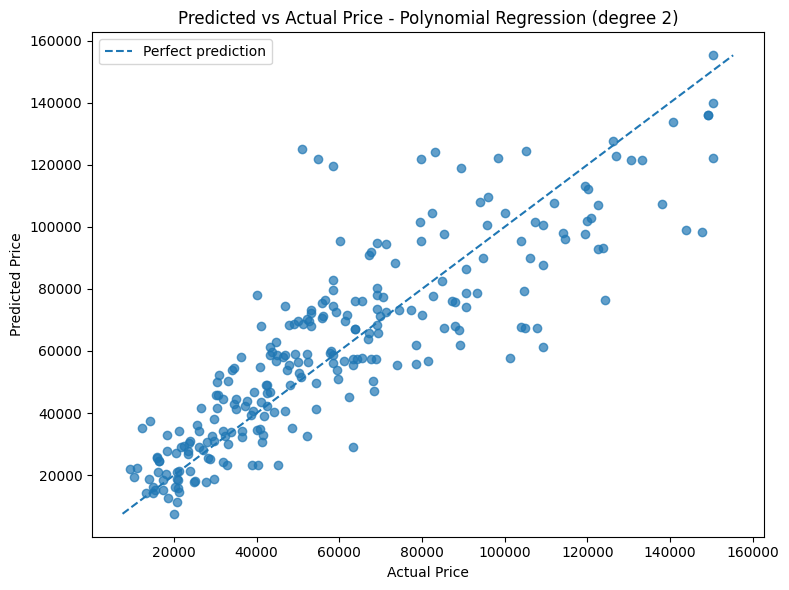

In [31]:
# Predicted vs actual
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, best_predictions, alpha=0.7)

minimum = min(y_test.min(), best_predictions.min())
maximum = max(y_test.max(), best_predictions.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_title(f"Predicted vs Actual Price - {best_name}")
ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")
ax.legend()

plt.tight_layout()
plt.show()

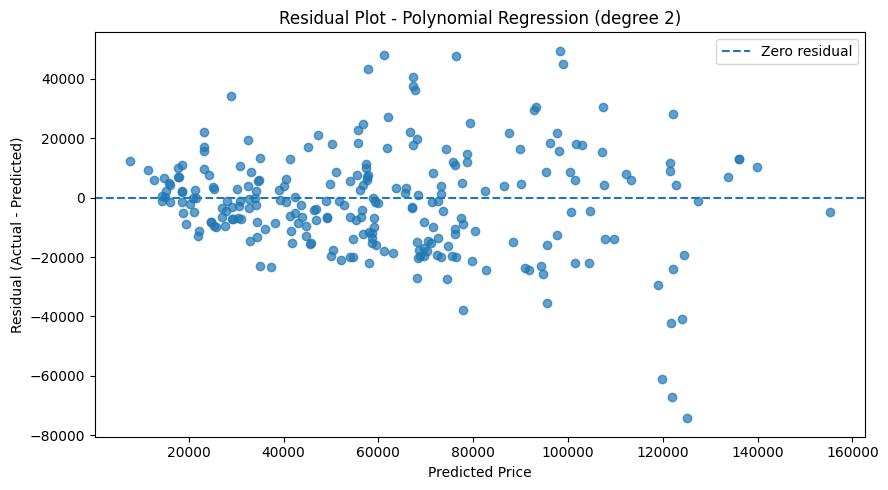

In [32]:
# Residual plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(best_predictions, best_residuals, alpha=0.7)

ax.axhline(
    0,
    linestyle="--",
    label="Zero residual"
)

ax.set_title(f"Residual Plot - {best_name}")
ax.set_xlabel("Predicted Price")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.legend()

plt.tight_layout()
plt.show()

### Diagnostic interpretation

The predicted-vs-actual plot shows that predictions follow the overall diagonal price trend, which is consistent with the model's relatively strong $R^2$. The points are not perfectly concentrated around the diagonal, so substantial individual prediction errors remain.

There is also a tendency for the model to overpredict at the upper end of the price range. The mean residual on the test set is approximately **-1,372 price units**, and the average residual becomes more negative in higher predicted-price quartiles.

The residual plot gives another important result: the residual spread increases as predicted price increases. The standard deviation of residuals rises from roughly **9,107** in the lowest prediction quartile to about **25,443** in the highest quartile. This widening spread indicates **heteroscedasticity-like behaviour**, meaning the size of prediction errors is not constant across the prediction range.

Approximately **18.9%** of the test observations have an absolute residual above 20,000 price units, so the model still has a noticeable set of large errors even though its overall $R^2$ is substantially above the linear baselines.

# 23. Coefficient analysis for the linear-family models

Coefficient magnitudes provide an interpretable view of how the linear-family models use the standardised predictors. Because the relevant pipelines apply `StandardScaler`, the coefficient magnitude can be compared across predictors on a common standardised scale.

For the best linear-family model in the final comparison, a positive coefficient means that a one-standard-deviation increase in the corresponding predictor is associated with an increase in predicted price while other predictors are held constant in the fitted model. A negative coefficient indicates the opposite direction.

This interpretation is associative rather than causal: a large coefficient means the predictor has a strong fitted contribution after the other variables are accounted for, not that changing the physical characteristic by itself would necessarily cause the observed price difference.

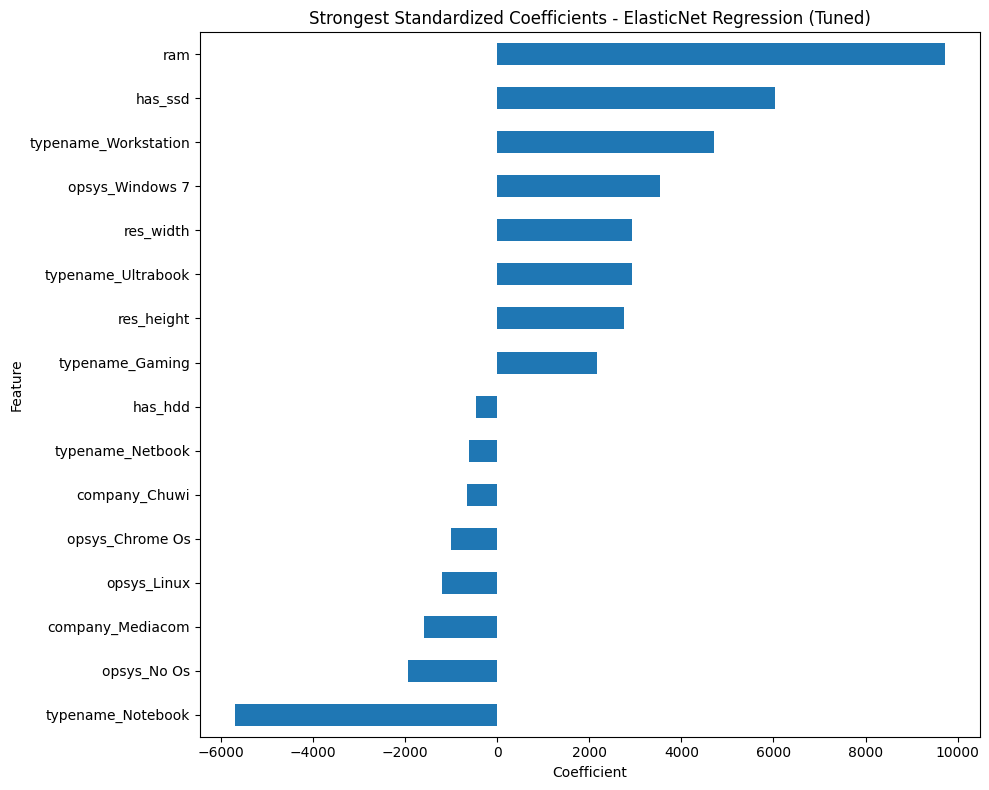

Best linear-family model: ElasticNet Regression (Tuned)


In [33]:
linear_family_candidates = {
    "Linear Regression": linear_model,
    "Ridge Regression (Tuned)": tuned_ridge,
    "Lasso Regression": lasso_model,
    "ElasticNet Regression (Tuned)": tuned_elasticnet
}

linear_family_results = final_results[
    final_results["Algorithm"].isin(linear_family_candidates.keys())
].copy()

best_linear_family_name = linear_family_results.iloc[0]["Algorithm"]
best_linear_family_model = linear_family_candidates[best_linear_family_name]

coef_series = pd.Series(
    best_linear_family_model.named_steps["model"].coef_,
    index=X_train.columns
).sort_values()

top_negative = coef_series.head(8)
top_positive = coef_series.tail(8)
coefficient_plot_data = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 8))
coefficient_plot_data.sort_values().plot(kind="barh")
plt.title(f"Strongest Standardized Coefficients - {best_linear_family_name}")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Best linear-family model:", best_linear_family_name)

### Coefficient-plot interpretation

The best linear-family model selected in this notebook is **tuned ElasticNet**. Its strongest positive standardised coefficients include `ram`, `has_ssd`, `typename_Workstation`, `res_width`, and `typename_Ultrabook`, while `typename_Notebook`, `opsys_No Os`, and several other category indicators carry negative coefficients.

The coefficient plot is useful because the features have been standardised before fitting, so the magnitudes are directly comparable in scale. The plot should still be interpreted as the fitted model's conditional associations, not as a causal ranking of hardware specifications.